# Main code

In [ ]:
# ============================================================
# Notebook Notes:
# ============================================================
# This notebook implements an extended baseline comparison for
# IntervalGP-VAE on the 24 synthetic proxy-based causal settings.
#
# Main goal:
#   Compare IntervalGP-VAE against several causal ITE estimation
#   baselines under the same synthetic latent-confounder setting.
#
# Compared methods:
#   1) IntervalGP-VAE
#      - Uses identifiable proxy-based latent confounder recovery.
#      - Uses local IntervalGP regularization during training.
#      - Uses latent GP posterior smoothing and ITE-space FullGP
#        posterior inference for ITE intervals.
#
#   2) Conformalized TEDVAE
#      - Uses the TEDVAE implementation aligned with the second code.
#      - Splits training data into fitting and calibration sets.
#      - Uses conformal calibration on ITE residuals to construct
#        90% ITE intervals.
#
#   3) CEVAE-like
#      - Uses a VAE-style latent confounder model.
#      - Reconstructs proxies, predicts treatment, and predicts outcome.
#      - Produces point ITE estimates.
#
#   4) DeepPCL-like
#      - Uses a representation network with treatment prediction,
#        outcome prediction, and treated-control balancing loss.
#      - Produces point ITE estimates.
#
#   5) BART/BCF-style ensemble
#      - Uses an ExtraTrees ensemble as a tree-based approximation.
#      - Uses bootstrap sampling to obtain ITE uncertainty intervals.
#
#   6) Conformalized TARNet
#      - Uses a TARNet-style shared representation with separate
#        potential-outcome heads.
#      - Uses conformal residual calibration to construct ITE intervals.
#
# Synthetic experiment design:
#   The experiment runs over 24 synthetic combinations generated from:
#      6 proxy-function sets
#      2 treatment-assignment mechanisms
#      2 outcome functions
#
# Synthetic data:
#   The data are generated from a latent-confounder setting:
#      U ~ N(0, 1)
#
#   Proxy variables Z are nonlinear transformations of U with noise.
#
#   Treatment assignment follows one of two logistic mechanisms:
#      T ~ Bernoulli(sigmoid(0.8U))
#      T ~ Bernoulli(sigmoid(0.4U + 0.3))
#
#   Outcomes follow one of two structural outcome functions:
#      Y = 0.5U + 0.2sin(U) + T(0.8 + 0.3U) + noise
#      Y = 0.5U + 0.3cos(U) + T(0.5 + 0.5U) + noise
#
# True ITE:
#   The true ITE is computed from the noiseless structural
#   counterfactual outcomes:
#      Y(1) - Y(0)
#
# IntervalGP-VAE configuration:
#   chosen_version = "u_aux"
#   latent_dim = 1
#   hidden_dim = 64
#   causal_head_hidden_dim = 64
#
# GP configuration:
#   GP_LENGTHSCALE = 7
#   GP_VARIANCE = 2.0
#   GP_NOISE = 1e-4
#
# IntervalGP-VAE training configuration:
#   BATCH_SIZE = 128
#   JOINT_EPOCHS = 200
#   HEAD_EPOCHS = 100
#   VAE_REFINE_EPOCHS = 50
#
# Optimizer:
#   AdamW is used with:
#      LR_JOINT = 1e-3
#      LR_HEAD = 1e-3
#      LR_VAE_REFINE = 1e-4
#      WEIGHT_DECAY = 1e-5
#
# Three-stage IntervalGP-VAE training:
#   Stage 1:
#      Jointly train the VAE and causal head.
#
#   Stage 2:
#      Freeze the VAE and train only the causal head.
#
#   Stage 3:
#      Freeze the causal head and refine the VAE.
#
# IntervalGP-VAE inference:
#   The notebook uses:
#      encoder posterior ITE sampling
#      latent GP posterior smoothing
#      ITE-space FullGP posterior prediction
#
# TEDVAE configuration:
#   TEDVAE_LATENT_DIM = 20
#   TEDVAE_LATENT_DIM_T = 10
#   TEDVAE_LATENT_DIM_Y = 10
#   TEDVAE_HIDDEN_DIM = 500
#   TEDVAE_NUM_LAYERS = 4
#   TEDVAE_NUM_SAMPLES = 10
#   TEDVAE_NUM_EPOCHS = 200
#   TEDVAE_BATCH_SIZE = 1000
#   TEDVAE_LR = 1e-3
#   TEDVAE_LR_DECAY = 0.01
#   TEDVAE_WEIGHT_DECAY = 1e-4
#
# Baseline training configuration:
#   BASELINE_EPOCHS = 300
#   BASELINE_BATCH_SIZE = 128
#   BASELINE_LR = 1e-3
#
#   Conformalized TEDVAE and Conformalized TARNet use a calibration
#   split to construct 90% intervals.
#
# ITE uncertainty:
#   ITE_CI = 0.90
#   Z_VALUE_90 = 1.6448536269514722
#
# Evaluation metrics:
#   PEHE
#   ATE
#   ATE error
#   90% empirical coverage
#   90% interval width
#   Interval score
#   Runtime
#
# Purpose:
#   This experiment provides a broader empirical comparison showing
#   how IntervalGP-VAE performs against latent-variable, representation-
#   learning, tree-ensemble, and conformalized neural baselines in terms
#   of point-estimation accuracy, uncertainty calibration, interval width,
#   and runtime.
# ============================================================


Iteration 1
IntervalGP-VAE PEHE      : 0.0232
IntervalGP-VAE ATE error : 0.0116
IntervalGP-VAE coverage  : 0.9600
IntervalGP-VAE width     : 0.1806
IntervalGP-VAE time      : 2.80 s
Conformalized TEDVAE PEHE test              : 0.0194
TConformalized EDVAE PEHE train             : 0.0229
Conformalized TEDVAE ATE error              : 0.0094
Conformalized TEDVAE conformal coverage     : 0.9800
Conformalized TEDVAE conformal width        : 0.0762
TEDVAE time                   : 9.32 s
CEVAE-like PEHE              : 0.0594
CEVAE-like ATE error         : 0.0292
CEVAE-like time              : 1.97 s
DeepPCL-like PEHE            : 0.0826
DeepPCL-like ATE error       : 0.0036
DeepPCL-like time            : 1.80 s
BART/BCF-style PEHE          : 0.2177
BART/BCF-style ATE error     : 0.1503
BART/BCF-style coverage      : 0.4600
BART/BCF-style width         : 0.3336
BART/BCF-style time          : 1.36 s
Conformalized TARNet PEHE    : 0.0812
Conformalized TARNet ATE err : 0.0286
Conformalized TARNe

,iteration_id,method,PEHE,ATE_error,coverage_90,mean_interval_width,interval_score,training_time_sec
0,1,IntervalGP-VAE,0.023228,0.011562,0.96,0.180639,0.198014,2.798722
1,1,Conformalized TEDVAE,0.019430,0.009357,0.98,0.076165,0.078964,9.321047
2,1,CEVAE-like,0.059444,0.029195,NaN,NaN,NaN,1.968119
3,1,DeepPCL-like,0.082571,0.003578,NaN,NaN,NaN,1.795943
4,1,BART/BCF-style ensemble,0.217686,0.150297,0.46,0.333560,1.120364,1.362194



Final summary


,method,PEHE_mean,PEHE_std,ATE_error_mean,ATE_error_std,coverage_90_mean,coverage_90_std,mean_interval_width_mean,mean_interval_width_std,interval_score_mean,interval_score_std,training_time_sec_mean,training_time_sec_std
0,BART/BCF-style ensemble,0.208843,0.050895,0.098319,0.046015,0.556667,0.142727,0.291352,0.033142,1.137521,0.462740,1.406291,0.097384
1,CEVAE-like,0.074650,0.022209,0.037863,0.020357,NaN,NaN,NaN,NaN,NaN,NaN,2.040751,0.103645
2,Conformalized TARNet,0.095942,0.013088,0.024911,0.019383,1.000000,0.000000,0.848565,0.057218,0.848565,0.057218,1.247447,0.046011
3,Conformalized TEDVAE,0.043600,0.029227,0.010136,0.008082,0.903333,0.063702,0.108297,0.026909,0.191360,0.128015,9.553433,0.415171
4,DeepPCL-like,0.113018,0.020749,0.032111,0.017890,NaN,NaN,NaN,NaN,NaN,NaN,1.825020,0.062431
5,IntervalGP-VAE,0.041219,0.014954,0.009393,0.005734,0.978333,0.025651,0.239306,0.060411,0.274109,0.086301,2.375263,0.092379


Saved summary to:
codeB_plus_extra_baselines_outputs/codeB_plus_extra_baselines_summary.csv


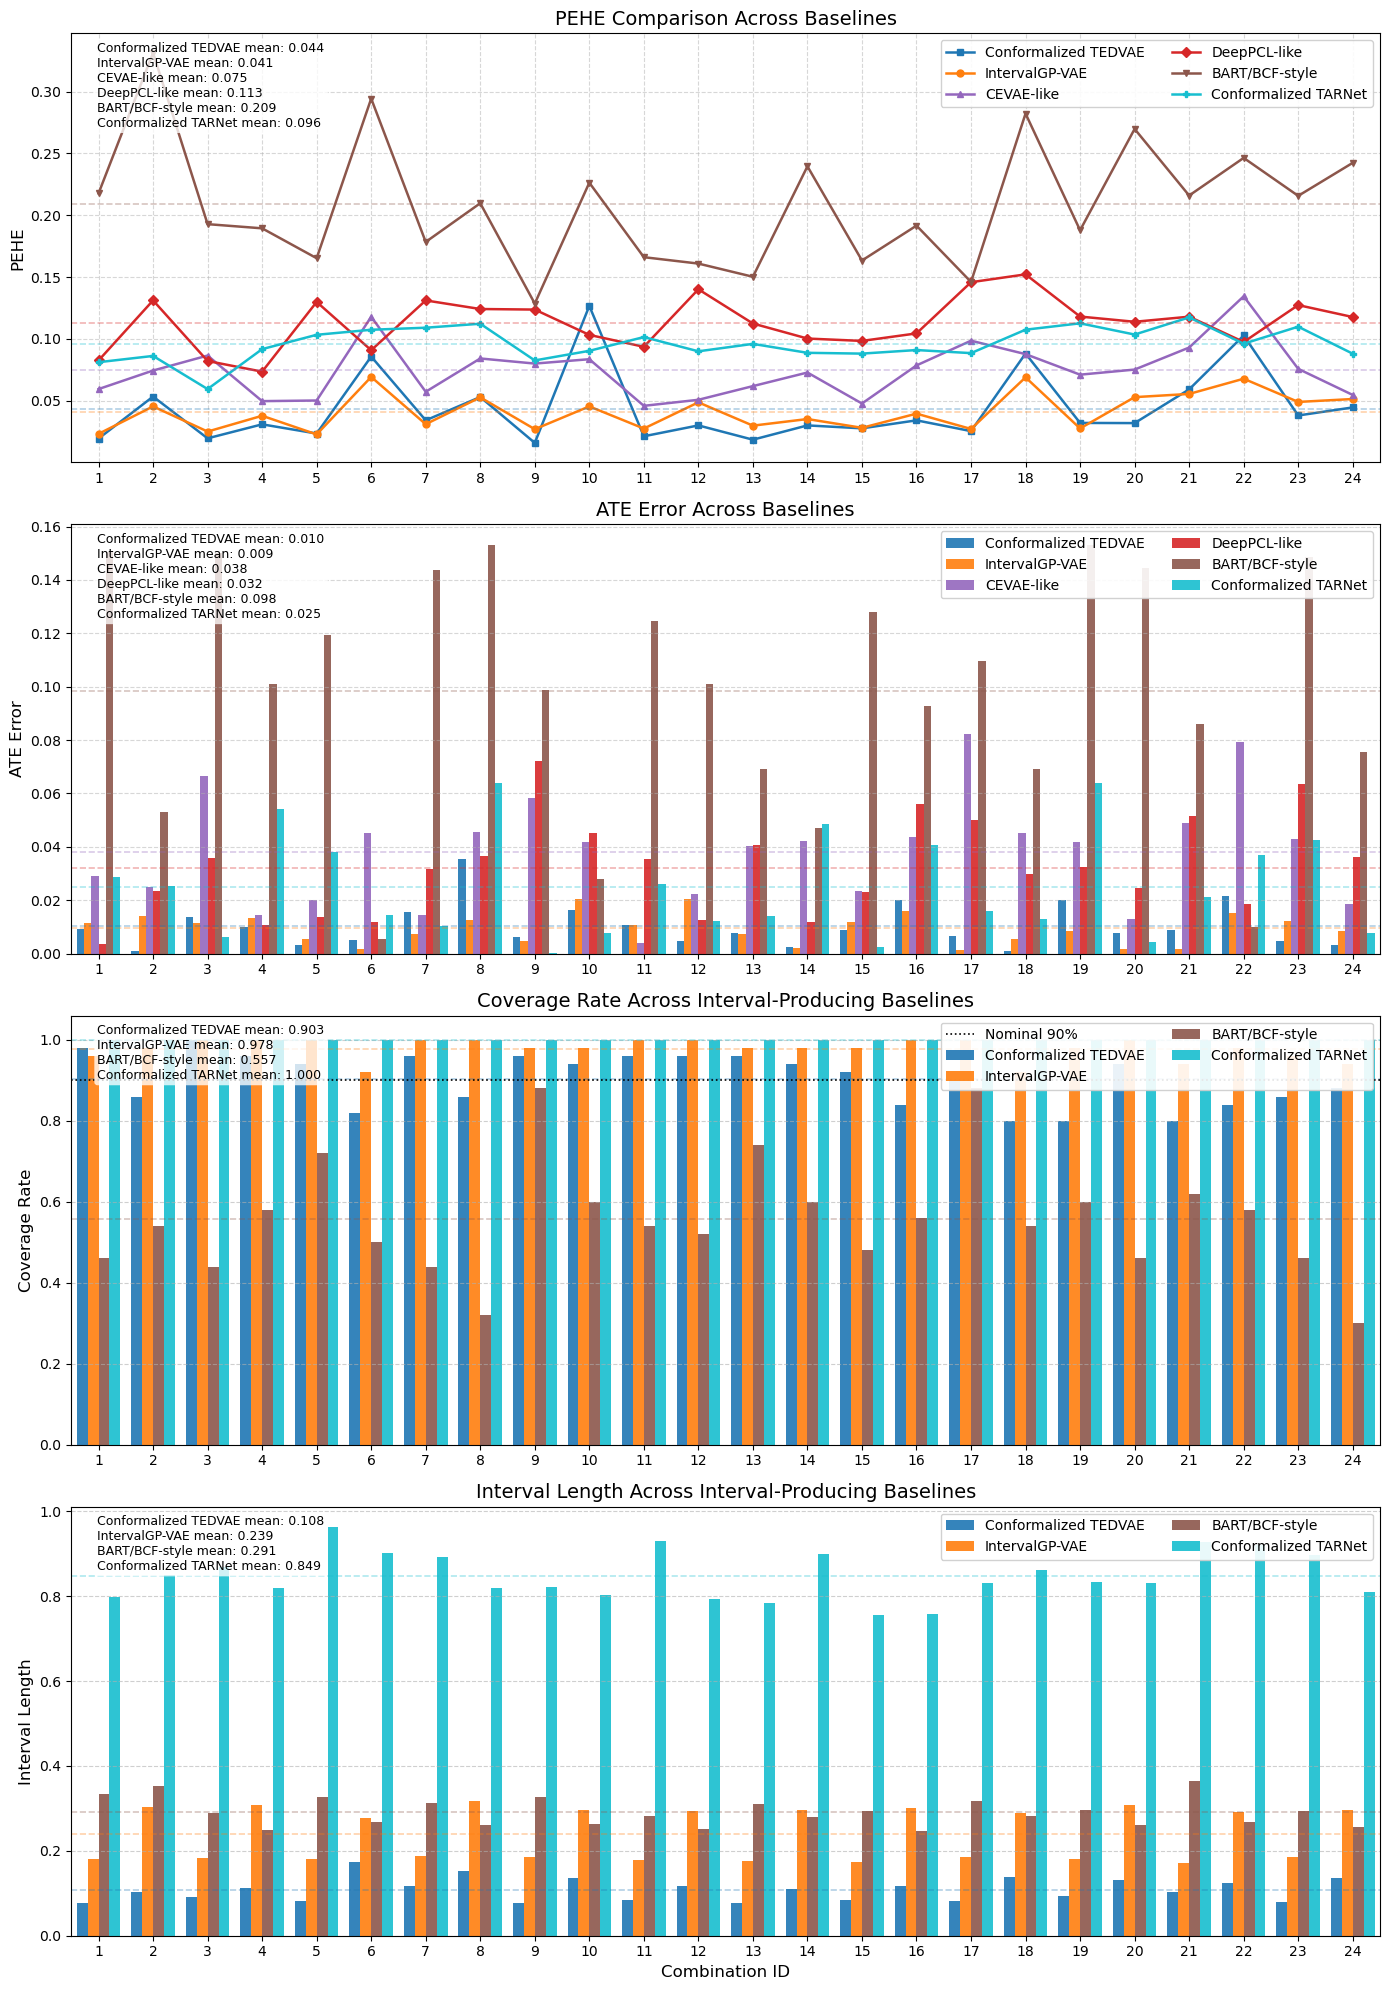

Saved extended baseline plot to: codeB_plus_extra_baselines_outputs/syn_results_extended_baselines_intervalgpvae_tedvae_consistent.png


In [1]:
# ============================================================
# 0. Imports and basic settings
# ============================================================
import os
import gc
import time
import math
import random
import inspect
import logging
import itertools
import warnings
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor

warnings.filterwarnings("ignore")

try:
    import pyro
    PYRO_AVAILABLE = True
except Exception as e:
    PYRO_AVAILABLE = False
    print("[Warning] Pyro is unavailable. TEDVAE will be skipped.")
    print("[Warning] Reason:", str(e))

try:
    from tedvae_gpu import TEDVAE
    TEDVAE_AVAILABLE = True
except Exception as e:
    TEDVAE_AVAILABLE = False
    print("[Warning] TEDVAE is unavailable. TEDVAE baseline will be skipped.")
    print("[Warning] Reason:", str(e))

if PYRO_AVAILABLE:
    logging.getLogger("pyro").setLevel(logging.ERROR)
    pyro.enable_validation(False)

torch.set_default_tensor_type(torch.FloatTensor)


# ============================================================
# 1. Global settings
# ============================================================

OUTPUT_DIR = "codeB_plus_extra_baselines_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

GLOBAL_SEED = 420

# Set to a small number for debugging, e.g. 2.
# Set to None to run all 24 combinations.
MAX_ITERATIONS = None

# ------------------------------------------------------------
# IntervalGP-VAE settings
# ------------------------------------------------------------
chosen_version = "u_aux"

INTERVALGPVAE_LATENT_DIM = 1
INTERVALGPVAE_HIDDEN_DIM = 64
CAUSAL_HEAD_HIDDEN_DIM = 64

GP_LENGTHSCALE = 7
GP_VARIANCE = 2.0
GP_NOISE = 1e-4

BATCH_SIZE = 128
JOINT_EPOCHS = 200
HEAD_EPOCHS = 100
VAE_REFINE_EPOCHS = 50

LR_JOINT = 1e-3
LR_HEAD = 1e-3
LR_VAE_REFINE = 1e-4
WEIGHT_DECAY = 1e-5

ITE_CI = 0.90
Z_VALUE_90 = 1.6448536269514722

MAX_GP_POINTS = None

# ------------------------------------------------------------
# Other baseline settings
# ------------------------------------------------------------
BASELINE_EPOCHS = 300
BASELINE_BATCH_SIZE = 128
BASELINE_LR = 1e-3

# TEDVAE settings exactly aligned with second code
TEDVAE_LATENT_DIM = 20
TEDVAE_LATENT_DIM_T = 10
TEDVAE_LATENT_DIM_Y = 10
TEDVAE_HIDDEN_DIM = 500
TEDVAE_NUM_LAYERS = 4
TEDVAE_NUM_SAMPLES = 10
TEDVAE_NUM_EPOCHS = 200
TEDVAE_BATCH_SIZE = 1000
TEDVAE_LR = 1e-3
TEDVAE_LR_DECAY = 0.01
TEDVAE_WEIGHT_DECAY = 1e-4

CALIBRATION_RATIO = 0.20


# ============================================================
# 2. Utility functions
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if PYRO_AVAILABLE:
        pyro.set_rng_seed(seed)


def cleanup_memory():
    plt.close("all")
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def to_numpy_1d(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    return np.asarray(x).reshape(-1)


def to_np(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def pehe_np(est_ite, true_ite):
    est_ite = to_numpy_1d(est_ite)
    true_ite = to_numpy_1d(true_ite)

    valid = np.isfinite(est_ite) & np.isfinite(true_ite)

    if valid.sum() == 0:
        return np.nan

    return float(np.sqrt(np.mean((est_ite[valid] - true_ite[valid]) ** 2)))


def ate_error_np(est_ite, true_ite):
    est_ite = to_numpy_1d(est_ite)
    true_ite = to_numpy_1d(true_ite)

    valid = np.isfinite(est_ite) & np.isfinite(true_ite)

    if valid.sum() == 0:
        return np.nan

    return float(abs(np.mean(est_ite[valid]) - np.mean(true_ite[valid])))


def interval_metrics_np(lower, upper, true_ite, alpha=0.10):
    lower = to_numpy_1d(lower)
    upper = to_numpy_1d(upper)
    true_ite = to_numpy_1d(true_ite)

    valid = (
        np.isfinite(lower)
        & np.isfinite(upper)
        & np.isfinite(true_ite)
    )

    if valid.sum() == 0:
        return np.nan, np.nan, np.nan

    lower = lower[valid]
    upper = upper[valid]
    true_ite = true_ite[valid]

    coverage = float(np.mean((lower <= true_ite) & (true_ite <= upper)))
    width = float(np.mean(upper - lower))

    below = true_ite < lower
    above = true_ite > upper

    score = (upper - lower).copy()
    score += (2.0 / alpha) * (lower - true_ite) * below
    score += (2.0 / alpha) * (true_ite - upper) * above
    score = float(np.mean(score))

    return coverage, width, score


def compute_interval_metrics(lower, upper, true_value):
    coverage, width, _ = interval_metrics_np(
        lower=lower,
        upper=upper,
        true_ite=true_value,
        alpha=0.10,
    )

    return {
        "coverage": coverage,
        "avg_length": width,
        "n": len(to_numpy_1d(true_value)),
    }


def split_fit_cal_indices(n, calibration_ratio=0.20, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)

    n_cal = max(1, int(n * calibration_ratio))
    cal_idx = idx[:n_cal]
    fit_idx = idx[n_cal:]

    return fit_idx, cal_idx


def conformal_abs_residual_quantile(y_true_cal, y_pred_cal, alpha=0.10):
    y_true_cal = to_numpy_1d(y_true_cal)
    y_pred_cal = to_numpy_1d(y_pred_cal)

    residuals = np.abs(y_true_cal - y_pred_cal)
    residuals = residuals[np.isfinite(residuals)]

    n = len(residuals)

    if n == 0:
        return np.nan

    q_level = np.ceil((n + 1) * (1 - alpha)) / n
    q_level = min(q_level, 1.0)

    return float(np.quantile(residuals, q_level, method="higher"))


def make_conformal_interval(point_pred, q_hat):
    point_pred = to_numpy_1d(point_pred)
    lower = point_pred - q_hat
    upper = point_pred + q_hat
    return lower, upper


def maybe_subsample_gp_reference(x, *ys, max_points=None, seed=0):
    n = x.shape[0]

    if max_points is None or n <= max_points:
        return (x, *ys)

    rng = np.random.default_rng(seed)
    idx = rng.choice(np.arange(n), size=max_points, replace=False)
    idx = np.sort(idx)

    idx_t = torch.tensor(idx, dtype=torch.long, device=x.device)

    out = [x[idx_t]]

    for y in ys:
        if torch.is_tensor(y):
            out.append(y[idx_t])
        else:
            out.append(np.asarray(y)[idx])

    return tuple(out)


# ============================================================
# 3. Synthetic data
# ============================================================

proxy_func_sets = [
    [
        lambda u, ua0, ua1: u,
        lambda u, ua0, ua1: u ** 2,
        lambda u, ua0, ua1: u ** 3,
        lambda u, ua0, ua1: torch.sin(u),
        lambda u, ua0, ua1: torch.tanh(u),
        lambda u, ua0, ua1: torch.exp(-0.5 * u ** 2),
    ],
    [
        lambda u, ua0, ua1: u,
        lambda u, ua0, ua1: torch.sin(u),
        lambda u, ua0, ua1: torch.tanh(0.5 * u),
        lambda u, ua0, ua1: torch.exp(0.3 * u),
        lambda u, ua0, ua1: torch.log1p(u ** 2),
        lambda u, ua0, ua1: torch.sigmoid(u),
    ],
    [
        lambda u, ua0, ua1: u,
        lambda u, ua0, ua1: u ** 2,
        lambda u, ua0, ua1: torch.sin(u),
        lambda u, ua0, ua1: torch.tanh(u),
        lambda u, ua0, ua1: torch.exp(-0.2 * u ** 2),
        lambda u, ua0, ua1: torch.sin(2 * u),
    ],
    [
        lambda u, ua0, ua1: u,
        lambda u, ua0, ua1: u ** 3,
        lambda u, ua0, ua1: torch.tanh(u),
        lambda u, ua0, ua1: torch.sigmoid(u),
        lambda u, ua0, ua1: torch.log1p(u ** 2),
        lambda u, ua0, ua1: torch.sin(u),
    ],
    [
        lambda u, ua0, ua1: u,
        lambda u, ua0, ua1: torch.tanh(0.5 * u),
        lambda u, ua0, ua1: torch.sin(u),
        lambda u, ua0, ua1: torch.exp(-0.3 * u ** 2),
        lambda u, ua0, ua1: torch.sigmoid(u),
        lambda u, ua0, ua1: u ** 2,
    ],
    [
        lambda u, ua0, ua1: u,
        lambda u, ua0, ua1: torch.log1p(torch.exp(u)),
        lambda u, ua0, ua1: torch.exp(0.5 * u),
        lambda u, ua0, ua1: torch.tanh(u),
        lambda u, ua0, ua1: torch.sigmoid(u),
        lambda u, ua0, ua1: torch.log1p(u ** 2),
    ],
]


def treat_func_linear_1(u_np, ua0_np=None):
    logits = 0.8 * u_np
    probs = 1.0 / (1.0 + np.exp(-logits))
    return np.random.binomial(1, probs).astype(np.float32).reshape(-1)


def treat_func_linear_2(u_np, ua0_np=None):
    logits = 0.4 * u_np + 0.3
    probs = 1.0 / (1.0 + np.exp(-logits))
    return np.random.binomial(1, probs).astype(np.float32).reshape(-1)


treatment_func_list = [
    treat_func_linear_1,
    treat_func_linear_2,
]


def outcome_func_1(u_np, t_np, ua0=None, ua1=None, noise_std=0.1):
    if t_np.ndim > 1:
        t_np = t_np.reshape(-1)

    base = (
        0.5 * u_np
        + 0.2 * np.sin(u_np)
        + t_np.reshape(-1, 1) * (0.8 + 0.3 * u_np)
    )

    noise = np.random.normal(0.0, noise_std, size=base.shape)
    return (base + noise).astype(np.float32)


def outcome_func_2(u_np, t_np, ua0=None, ua1=None, noise_std=0.1):
    if t_np.ndim > 1:
        t_np = t_np.reshape(-1)

    base = (
        0.5 * u_np
        + 0.3 * np.cos(u_np)
        + t_np.reshape(-1, 1) * (0.5 + 0.5 * u_np)
    )

    noise = np.random.normal(0.0, noise_std, size=base.shape)
    return (base + noise).astype(np.float32)


outcome_func_list = [
    outcome_func_1,
    outcome_func_2,
]


def generate_synthetic_data_with_aux_uas(
    n=1000,
    noise_std=0.1,
    seed=0,
    num_proxies=None,
    proxy_funcs=None,
    outcome_func=None,
    treatment_func=None,
):
    if seed is not None:
        set_seed(seed)

    u_np = np.random.normal(0, 1, size=(n, 1)).astype(np.float32)
    ua0_np = np.random.normal(0, 1, size=(n, 1)).astype(np.float32)
    ua1_np = np.random.normal(0, 1, size=(n, 1)).astype(np.float32)

    u_tensor = torch.from_numpy(u_np)
    ua0_tensor = torch.from_numpy(ua0_np)
    ua1_tensor = torch.from_numpy(ua1_np)

    if proxy_funcs is None:
        proxy_funcs = proxy_func_sets[0]

    if num_proxies is None:
        num_proxies = len(proxy_funcs)

    proxy_funcs = proxy_funcs[:num_proxies]

    clean_z = torch.cat(
        [g(u_tensor, ua0_tensor, ua1_tensor) for g in proxy_funcs],
        dim=1,
    )

    eps_z = torch.randn(n, num_proxies) * noise_std
    z_tensor = clean_z + eps_z

    if treatment_func is None:
        treatment_func = treat_func_linear_1

    t_np = treatment_func(u_np, ua0_np)
    t_tensor = torch.from_numpy(t_np.astype(np.float32))

    if outcome_func is None:
        outcome_func = outcome_func_1

    y_np = outcome_func(
        u_np,
        t_np,
        ua0_np,
        ua1_np,
        noise_std=noise_std,
    )

    y_tensor = torch.from_numpy(y_np.squeeze()).float()

    return {
        "z": z_tensor.float(),
        "t": t_tensor.float(),
        "y": y_tensor.float(),
        "u": u_tensor.squeeze().float(),
        "ua0": ua0_tensor.squeeze().float(),
        "ua1": ua1_tensor.squeeze().float(),
        "proxy_funcs": proxy_funcs,
        "outcome_func": outcome_func,
        "treatment_func": treatment_func,
    }


def call_outcome_func(
    outcome_func,
    u_np,
    t_np,
    z_np=None,
    ua0_np=None,
    ua1_np=None,
    noise_std=0.0,
):
    if torch.is_tensor(u_np):
        u_np = u_np.detach().cpu().numpy()

    if torch.is_tensor(t_np):
        t_np = t_np.detach().cpu().numpy()

    if ua0_np is not None and torch.is_tensor(ua0_np):
        ua0_np = ua0_np.detach().cpu().numpy()

    if ua1_np is not None and torch.is_tensor(ua1_np):
        ua1_np = ua1_np.detach().cpu().numpy()

    return outcome_func(
        u_np,
        t_np,
        ua0_np,
        ua1_np,
        noise_std=noise_std,
    )


def compute_true_ite_from_data(
    data,
    z_for_outcome,
    outcome_func,
):
    u_np = data["u"].detach().cpu().numpy().reshape(-1, 1)

    ua0 = data.get("ua0", None)
    ua1 = data.get("ua1", None)

    ua0_np = ua0.detach().cpu().numpy().reshape(-1, 1) if ua0 is not None else None
    ua1_np = ua1.detach().cpu().numpy().reshape(-1, 1) if ua1 is not None else None

    t0_np = np.zeros_like(u_np)
    t1_np = np.ones_like(u_np)

    y0 = call_outcome_func(
        outcome_func=outcome_func,
        u_np=u_np,
        t_np=t0_np,
        z_np=to_np(z_for_outcome),
        ua0_np=ua0_np,
        ua1_np=ua1_np,
        noise_std=0.0,
    )

    y1 = call_outcome_func(
        outcome_func=outcome_func,
        u_np=u_np,
        t_np=t1_np,
        z_np=to_np(z_for_outcome),
        ua0_np=ua0_np,
        ua1_np=ua1_np,
        noise_std=0.0,
    )

    return (y1 - y0).reshape(-1)


# ============================================================
# 4. IntervalGP-VAE model
# ============================================================

class DoubleEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, use_auxiliary_latents=False):
        super().__init__()

        self.use_aux = use_auxiliary_latents
        self.fc1 = nn.Linear(input_dim, hidden_dim)

        self.mean_u = nn.Linear(hidden_dim, latent_dim)
        self.logvar_u = nn.Linear(hidden_dim, latent_dim)

        self.mean_eps = nn.Linear(hidden_dim, input_dim)
        self.logvar_eps = nn.Linear(hidden_dim, input_dim)

        if self.use_aux:
            self.mean_ua0 = nn.Linear(hidden_dim, latent_dim)
            self.logvar_ua0 = nn.Linear(hidden_dim, latent_dim)

            self.mean_ua1 = nn.Linear(hidden_dim, latent_dim)
            self.logvar_ua1 = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z):
        h = F.relu(self.fc1(z))

        mu_u = self.mean_u(h)
        logvar_u = self.logvar_u(h)
        std_u = torch.exp(0.5 * logvar_u)

        mu_eps = self.mean_eps(h)
        logvar_eps = self.logvar_eps(h)
        std_eps = torch.exp(0.5 * logvar_eps)

        if self.use_aux:
            mu_ua0 = self.mean_ua0(h)
            logvar_ua0 = self.logvar_ua0(h)
            std_ua0 = torch.exp(0.5 * logvar_ua0)

            mu_ua1 = self.mean_ua1(h)
            logvar_ua1 = self.logvar_ua1(h)
            std_ua1 = torch.exp(0.5 * logvar_ua1)

            return (
                mu_u, std_u, logvar_u,
                mu_eps, std_eps, logvar_eps,
                mu_ua0, std_ua0, logvar_ua0,
                mu_ua1, std_ua1, logvar_ua1,
            )

        return mu_u, std_u, logvar_u, mu_eps, std_eps, logvar_eps


class AdditiveDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim, use_auxiliary_latents=False):
        super().__init__()

        self.use_aux = use_auxiliary_latents
        factor = 1 + (2 if use_auxiliary_latents else 0)

        self.fc1 = nn.Linear(latent_dim * factor, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, u, eps, ua0=None, ua1=None):
        if self.use_aux:
            x = torch.cat([u, ua0, ua1], dim=1)
        else:
            x = u

        h = F.relu(self.fc1(x))
        return self.out(h) + eps


class GPVAEwithNoise(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        latent_dim,
        gp_lengthscale=GP_LENGTHSCALE,
        gp_variance=GP_VARIANCE,
        gp_noise=GP_NOISE,
        use_auxiliary_latents=False,
    ):
        super().__init__()

        self.use_aux = use_auxiliary_latents

        self.encoder = DoubleEncoder(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
            use_auxiliary_latents=use_auxiliary_latents,
        )

        self.decoder = AdditiveDecoder(
            latent_dim=latent_dim,
            hidden_dim=hidden_dim,
            output_dim=input_dim,
            use_auxiliary_latents=use_auxiliary_latents,
        )

        self.gp_lengthscale = gp_lengthscale
        self.gp_variance = gp_variance
        self.gp_noise = gp_noise

    def reparameterize(self, mu, std):
        return mu + torch.randn_like(std) * std

    def local_interval_gp_regularizer(self, z, mu_u, std_u):
        k_ii = self.gp_variance * torch.ones_like(mu_u)
        gp_std = torch.sqrt(k_ii + self.gp_noise)

        lower = mu_u - std_u
        upper = mu_u + std_u

        normal = torch.distributions.Normal(
            loc=torch.zeros_like(mu_u),
            scale=gp_std,
        )

        prob = normal.cdf(upper) - normal.cdf(lower)
        prob = torch.clamp(prob, min=1e-8)

        return -torch.sum(torch.log(prob))

    def get_latent_stats(self, z, var_name="u"):
        outputs = self.encoder(z)

        if var_name == "u":
            return outputs[0], outputs[1], outputs[2]

        if var_name == "eps":
            return outputs[3], outputs[4], outputs[5]

        if var_name == "ua0":
            if not self.use_aux:
                return None, None, None
            return outputs[6], outputs[7], outputs[8]

        if var_name == "ua1":
            if not self.use_aux:
                return None, None, None
            return outputs[9], outputs[10], outputs[11]

        raise ValueError(f"Invalid var_name: {var_name}")

    def sample_latent(self, z, var_name="u"):
        mu, std, _ = self.get_latent_stats(z, var_name=var_name)

        if mu is None:
            return None

        return self.reparameterize(mu, std)

    def forward(self, z):
        if self.use_aux:
            (
                mu_u, std_u, logvar_u,
                mu_eps, std_eps, logvar_eps,
                mu_ua0, std_ua0, logvar_ua0,
                mu_ua1, std_ua1, logvar_ua1,
            ) = self.encoder(z)

            u = self.reparameterize(mu_u, std_u)
            eps = self.reparameterize(mu_eps, std_eps)
            ua0 = self.reparameterize(mu_ua0, std_ua0)
            ua1 = self.reparameterize(mu_ua1, std_ua1)

            z_recon = self.decoder(u, eps, ua0=ua0, ua1=ua1)

        else:
            mu_u, std_u, logvar_u, mu_eps, std_eps, logvar_eps = self.encoder(z)

            u = self.reparameterize(mu_u, std_u)
            eps = self.reparameterize(mu_eps, std_eps)
            ua0 = None
            ua1 = None

            z_recon = self.decoder(u, eps)

        recon_loss = F.mse_loss(z_recon, z, reduction="sum")

        kl_u = -0.001 * torch.sum(
            1 + logvar_u - mu_u.pow(2) - logvar_u.exp()
        )

        kl_eps = -0.5 * torch.sum(
            1 + logvar_eps - mu_eps.pow(2) - logvar_eps.exp()
        )

        gp_interval_reg = self.local_interval_gp_regularizer(
            z=z,
            mu_u=mu_u,
            std_u=std_u,
        )

        std_penalty = torch.sum(std_u ** 2)

        total_loss = (
            recon_loss
            + kl_u
            + kl_eps
            + gp_interval_reg
            + 10.0 * std_penalty
        )

        if self.use_aux:
            kl_ua0 = -0.5 * torch.sum(
                1 + logvar_ua0 - mu_ua0.pow(2) - logvar_ua0.exp()
            )

            kl_ua1 = -0.5 * torch.sum(
                1 + logvar_ua1 - mu_ua1.pow(2) - logvar_ua1.exp()
            )

            total_loss = total_loss + kl_ua0 + kl_ua1

        return total_loss, {
            "recon_loss": recon_loss.item(),
            "kl_u": kl_u.item(),
            "kl_eps": kl_eps.item(),
            "gp_interval_reg": gp_interval_reg.item(),
            "u": u,
            "eps": eps,
            "ua0": ua0,
            "ua1": ua1,
            "mu_u": mu_u,
            "std_u": std_u,
            "z_recon": z_recon,
        }


class FlexibleCausalHead(nn.Module):
    def __init__(
        self,
        latent_dim_u,
        hidden_dim=CAUSAL_HEAD_HIDDEN_DIM,
        z_y_dim=None,
        use_auxiliary_latents=False,
    ):
        super().__init__()

        self.use_aux = use_auxiliary_latents
        self.z_y_dim = z_y_dim

        input_dim = latent_dim_u + 1

        if z_y_dim is not None:
            input_dim += z_y_dim

        if use_auxiliary_latents:
            input_dim += latent_dim_u

        self.fc = nn.Linear(input_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, u, t, z_y=None, ua1=None):
        t = t.view(-1, 1)

        parts = [u, t]

        if self.z_y_dim is not None:
            if z_y is None:
                raise ValueError("Expected z_y input but got None.")
            parts.append(z_y)

        if self.use_aux:
            if ua1 is None:
                raise ValueError("Expected ua1 input but got None.")
            parts.append(ua1)

        x = torch.cat(parts, dim=1)
        h = F.relu(self.fc(x))

        return self.out(h)


class CausalGPVAEwithNoise(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        latent_dim,
        z_y_dim=None,
        use_auxiliary_latents=False,
        gp_lengthscale=GP_LENGTHSCALE,
        gp_variance=GP_VARIANCE,
        gp_noise=GP_NOISE,
    ):
        super().__init__()

        self.z_y_dim = z_y_dim
        self.use_aux = use_auxiliary_latents

        self.vae = GPVAEwithNoise(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
            gp_lengthscale=gp_lengthscale,
            gp_variance=gp_variance,
            gp_noise=gp_noise,
            use_auxiliary_latents=use_auxiliary_latents,
        )

        self.causal_head = FlexibleCausalHead(
            latent_dim_u=latent_dim,
            hidden_dim=CAUSAL_HEAD_HIDDEN_DIM,
            z_y_dim=z_y_dim,
            use_auxiliary_latents=use_auxiliary_latents,
        )

    def forward(self, z, t, y):
        loss_vae, vae_info = self.vae(z)

        u = vae_info["u"]
        ua1 = vae_info["ua1"] if self.use_aux else None

        z_y = make_z_y(self, z)

        y_pred = self.causal_head(
            u,
            t,
            z_y=z_y,
            ua1=ua1,
        )

        causal_loss = F.mse_loss(
            y_pred,
            y.unsqueeze(-1),
            reduction="sum",
        )

        total_loss = loss_vae + causal_loss

        return total_loss, {
            **vae_info,
            "y_pred": y_pred,
            "causal_loss": causal_loss.item(),
        }


# ============================================================
# 5. IntervalGP-VAE posterior functions
# ============================================================

def rbf_kernel(x1, x2=None, lengthscale=1.0, variance=1.0):
    if x2 is None:
        x2 = x1

    if x1.ndim == 1:
        x1 = x1.view(-1, 1)

    if x2.ndim == 1:
        x2 = x2.view(-1, 1)

    dists = torch.cdist(x1, x2).pow(2)

    return variance * torch.exp(-0.5 * dists / (lengthscale ** 2))


def full_gp_posterior_point(
    x_train,
    y_train,
    x_test,
    lengthscale=GP_LENGTHSCALE,
    variance=GP_VARIANCE,
    noise=GP_NOISE,
    jitter=1e-5,
):
    x_train = x_train.float()
    x_test = x_test.float()
    y_train = y_train.float().view(-1, 1)

    n_train = x_train.shape[0]
    n_test = x_test.shape[0]

    K = rbf_kernel(
        x_train,
        x_train,
        lengthscale=lengthscale,
        variance=variance,
    )

    K = K + noise * torch.eye(n_train, device=x_train.device)

    K_s = rbf_kernel(
        x_train,
        x_test,
        lengthscale=lengthscale,
        variance=variance,
    )

    K_ss = rbf_kernel(
        x_test,
        x_test,
        lengthscale=lengthscale,
        variance=variance,
    )

    K_ss = K_ss + jitter * torch.eye(n_test, device=x_test.device)

    current_jitter = jitter

    for _ in range(8):
        try:
            L = torch.linalg.cholesky(
                K + current_jitter * torch.eye(n_train, device=x_train.device)
            )
            break
        except RuntimeError:
            current_jitter *= 10
    else:
        raise RuntimeError("Cholesky failed in full_gp_posterior_point.")

    alpha = torch.cholesky_solve(y_train, L)

    posterior_mean = K_s.t() @ alpha

    v = torch.cholesky_solve(K_s, L)
    posterior_cov = K_ss - K_s.t() @ v
    posterior_cov = 0.5 * (posterior_cov + posterior_cov.t())

    return posterior_mean.squeeze(-1), posterior_cov


def full_gp_posterior_heteroscedastic(
    x_train,
    y_train,
    x_test,
    noise_var_train,
    lengthscale=GP_LENGTHSCALE,
    variance=GP_VARIANCE,
    min_noise=GP_NOISE,
    jitter=1e-5,
):
    x_train = x_train.float()
    x_test = x_test.float()
    y_train = y_train.float().view(-1, 1)

    noise_var_train = noise_var_train.float().view(-1)
    noise_var_train = torch.clamp(noise_var_train, min=min_noise)

    n_train = x_train.shape[0]
    n_test = x_test.shape[0]

    K = rbf_kernel(
        x_train,
        x_train,
        lengthscale=lengthscale,
        variance=variance,
    )

    K = K + torch.diag(noise_var_train)

    K_s = rbf_kernel(
        x_train,
        x_test,
        lengthscale=lengthscale,
        variance=variance,
    )

    K_ss = rbf_kernel(
        x_test,
        x_test,
        lengthscale=lengthscale,
        variance=variance,
    )

    K_ss = K_ss + jitter * torch.eye(n_test, device=x_test.device)

    current_jitter = jitter

    for _ in range(8):
        try:
            L = torch.linalg.cholesky(
                K + current_jitter * torch.eye(n_train, device=x_train.device)
            )
            break
        except RuntimeError:
            current_jitter *= 10
    else:
        raise RuntimeError("Cholesky failed in full_gp_posterior_heteroscedastic.")

    alpha = torch.cholesky_solve(y_train, L)
    posterior_mean = K_s.t() @ alpha

    v = torch.cholesky_solve(K_s, L)
    posterior_cov = K_ss - K_s.t() @ v
    posterior_cov = 0.5 * (posterior_cov + posterior_cov.t())

    return posterior_mean.squeeze(-1), posterior_cov


def latent_gp_posterior_smoothing(
    z_train,
    mu_u_train,
    z_test,
    lengthscale=GP_LENGTHSCALE,
    variance=GP_VARIANCE,
    noise=GP_NOISE,
):
    if mu_u_train.ndim == 1:
        mu_u_train = mu_u_train.view(-1, 1)

    latent_dim = mu_u_train.shape[1]
    means = []
    vars_diag = []

    for r in range(latent_dim):
        mean_r, cov_r = full_gp_posterior_point(
            x_train=z_train,
            y_train=mu_u_train[:, r],
            x_test=z_test,
            lengthscale=lengthscale,
            variance=variance,
            noise=noise,
        )

        var_r = torch.diag(cov_r).clamp_min(1e-8)

        means.append(mean_r)
        vars_diag.append(var_r)

    mean = torch.stack(means, dim=1)
    std = torch.sqrt(torch.stack(vars_diag, dim=1))

    return mean, std


def make_z_y(model, z):
    if model.causal_head.z_y_dim == z.shape[1]:
        return z

    if model.causal_head.z_y_dim:
        return z[:, z.shape[1] // 2:]

    return None


def sample_ite_from_encoder(
    model,
    z,
    n_samples=100,
):
    model.eval()

    with torch.no_grad():
        mu_u, std_u, _ = model.vae.get_latent_stats(z, var_name="u")
        N, d_u = mu_u.shape
        device = z.device

        z_y = make_z_y(model, z)

        mu_ua1, std_ua1, _ = model.vae.get_latent_stats(z, var_name="ua1")
        has_ua1 = (mu_ua1 is not None) and (std_ua1 is not None)

        eps_u = torch.randn(n_samples, N, d_u, device=device)
        u_samples = mu_u.unsqueeze(0) + eps_u * std_u.unsqueeze(0)

        U = u_samples.reshape(-1, d_u)

        if has_ua1:
            d_ua = mu_ua1.shape[1]
            eps_ua1 = torch.randn(n_samples, N, d_ua, device=device)
            ua1_samples = mu_ua1.unsqueeze(0) + eps_ua1 * std_ua1.unsqueeze(0)
            UA1 = ua1_samples.reshape(-1, d_ua)
        else:
            UA1 = None

        if z_y is not None:
            ZY = (
                z_y.unsqueeze(0)
                .expand(n_samples, -1, -1)
                .reshape(-1, z_y.shape[1])
            )
        else:
            ZY = None

        t0 = torch.zeros(U.shape[0], device=device)
        t1 = torch.ones(U.shape[0], device=device)

        y0 = model.causal_head(U, t0, z_y=ZY, ua1=UA1).squeeze(-1)
        y1 = model.causal_head(U, t1, z_y=ZY, ua1=UA1).squeeze(-1)

        ite_samples = (y1 - y0).view(n_samples, N)

        lower_q = (1.0 - ITE_CI) / 2.0
        upper_q = 1.0 - lower_q

        ite_mean = ite_samples.mean(dim=0)
        ite_std = ite_samples.std(dim=0)
        ite_lower = ite_samples.quantile(lower_q, dim=0)
        ite_upper = ite_samples.quantile(upper_q, dim=0)

        return ite_samples, ite_mean, ite_std, ite_lower, ite_upper


def ite_space_intervalgp_head(
    model,
    z_train,
    z_test,
    n_samples=100,
    lengthscale=GP_LENGTHSCALE,
    variance=GP_VARIANCE,
    min_noise=GP_NOISE,
):
    model.eval()

    with torch.no_grad():
        _, ite_mean_train, ite_std_train, ite_lower_train, ite_upper_train = (
            sample_ite_from_encoder(
                model=model,
                z=z_train,
                n_samples=n_samples,
            )
        )

        mu_u_train, _, _ = model.vae.get_latent_stats(z_train, var_name="u")
        mu_u_test, _, _ = model.vae.get_latent_stats(z_test, var_name="u")

        u_test_smooth, u_test_smooth_std = latent_gp_posterior_smoothing(
            z_train=z_train,
            mu_u_train=mu_u_train,
            z_test=z_test,
            lengthscale=lengthscale,
            variance=variance,
            noise=min_noise,
        )

        u_train_smooth = mu_u_train.detach()

        (
            u_train_gp,
            ite_lower_train_gp,
            ite_upper_train_gp,
            ite_mean_train_gp,
            ite_std_train_gp,
        ) = maybe_subsample_gp_reference(
            u_train_smooth,
            ite_lower_train.detach(),
            ite_upper_train.detach(),
            ite_mean_train.detach(),
            ite_std_train.detach(),
            max_points=MAX_GP_POINTS,
            seed=123,
        )

        noise_var_lower = ite_std_train_gp.pow(2) + min_noise
        noise_var_upper = ite_std_train_gp.pow(2) + min_noise
        noise_var_mean = ite_std_train_gp.pow(2) + min_noise

        gp_lower_mean, gp_lower_cov = full_gp_posterior_heteroscedastic(
            x_train=u_train_gp,
            y_train=ite_lower_train_gp,
            x_test=u_test_smooth,
            noise_var_train=noise_var_lower,
            lengthscale=lengthscale,
            variance=variance,
            min_noise=min_noise,
        )

        gp_upper_mean, gp_upper_cov = full_gp_posterior_heteroscedastic(
            x_train=u_train_gp,
            y_train=ite_upper_train_gp,
            x_test=u_test_smooth,
            noise_var_train=noise_var_upper,
            lengthscale=lengthscale,
            variance=variance,
            min_noise=min_noise,
        )

        gp_ite_mean, gp_ite_cov = full_gp_posterior_heteroscedastic(
            x_train=u_train_gp,
            y_train=ite_mean_train_gp,
            x_test=u_test_smooth,
            noise_var_train=noise_var_mean,
            lengthscale=lengthscale,
            variance=variance,
            min_noise=min_noise,
        )

        gp_lower_std = torch.sqrt(torch.diag(gp_lower_cov).clamp_min(1e-8))
        gp_upper_std = torch.sqrt(torch.diag(gp_upper_cov).clamp_min(1e-8))

        raw_lower = torch.minimum(gp_lower_mean, gp_upper_mean)
        raw_upper = torch.maximum(gp_lower_mean, gp_upper_mean)

        ite_lower_test = raw_lower - Z_VALUE_90 * gp_lower_std
        ite_upper_test = raw_upper + Z_VALUE_90 * gp_upper_std

        return {
            "ite_mean_test": gp_ite_mean,
            "ite_lower_test": ite_lower_test,
            "ite_upper_test": ite_upper_test,
            "u_test_smooth": u_test_smooth,
            "u_test_smooth_std": u_test_smooth_std,
            "u_test_raw": mu_u_test,
        }


# ============================================================
# 6. IntervalGP-VAE training wrapper
# ============================================================

def train_and_eval_intervalgpvae(
    z_train_all,
    t_train_all,
    y_train_all,
    u_train_true_all,
    z_test,
    true_ite_np,
    true_ate,
    iteration_id,
    device=DEVICE,
):
    set_seed(GLOBAL_SEED + iteration_id)

    use_aux = chosen_version == "u_aux"

    if chosen_version == "z_to_y":
        z_y_dim = z_train_all.shape[1]
    elif chosen_version == "split_z_to_t_and_y":
        z_y_dim = z_train_all.shape[1] // 2
    else:
        z_y_dim = None

    loader = DataLoader(
        TensorDataset(
            z_train_all,
            t_train_all,
            y_train_all,
            u_train_true_all,
        ),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )

    model = CausalGPVAEwithNoise(
        input_dim=z_train_all.shape[1],
        hidden_dim=INTERVALGPVAE_HIDDEN_DIM,
        latent_dim=INTERVALGPVAE_LATENT_DIM,
        z_y_dim=z_y_dim,
        use_auxiliary_latents=use_aux,
        gp_lengthscale=GP_LENGTHSCALE,
        gp_variance=GP_VARIANCE,
        gp_noise=GP_NOISE,
    ).to(device)

    start_time = time.time()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR_JOINT,
        weight_decay=WEIGHT_DECAY,
    )

    for epoch in range(JOINT_EPOCHS):
        model.train()

        for batch in loader:
            z_batch, t_batch, y_batch, _ = [b.to(device) for b in batch]

            loss, _ = model(z_batch, t_batch, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    for param in model.vae.parameters():
        param.requires_grad = False

    for param in model.causal_head.parameters():
        param.requires_grad = True

    causal_optimizer = torch.optim.AdamW(
        model.causal_head.parameters(),
        lr=LR_HEAD,
        weight_decay=WEIGHT_DECAY,
    )

    for epoch in range(HEAD_EPOCHS):
        model.train()

        for z_batch, t_batch, y_batch, _ in loader:
            z_batch = z_batch.to(device)
            t_batch = t_batch.to(device)
            y_batch = y_batch.to(device)

            with torch.no_grad():
                mu_u = model.vae.get_latent_stats(
                    z_batch,
                    var_name="u",
                )[0]

                if model.use_aux:
                    mu_ua1, std_ua1, _ = model.vae.get_latent_stats(
                        z_batch,
                        var_name="ua1",
                    )

                    ua1_batch = model.vae.reparameterize(
                        mu_ua1,
                        std_ua1,
                    )
                else:
                    ua1_batch = None

            z_y_batch = make_z_y(model, z_batch)

            y_pred = model.causal_head(
                mu_u.detach(),
                t_batch,
                z_y=z_y_batch,
                ua1=ua1_batch.detach() if ua1_batch is not None else None,
            )

            causal_loss = F.mse_loss(
                y_pred,
                y_batch.unsqueeze(-1),
            )

            causal_optimizer.zero_grad()
            causal_loss.backward()
            causal_optimizer.step()

    for param in model.causal_head.parameters():
        param.requires_grad = False

    for param in model.vae.parameters():
        param.requires_grad = True

    vae_optimizer = torch.optim.AdamW(
        model.vae.parameters(),
        lr=LR_VAE_REFINE,
        weight_decay=WEIGHT_DECAY,
    )

    for epoch in range(VAE_REFINE_EPOCHS):
        model.train()

        for batch in loader:
            z_batch, t_batch, y_batch, _ = [b.to(device) for b in batch]

            z_y_batch = make_z_y(model, z_batch)

            loss_vae, vae_info = model.vae(z_batch)

            ua1_batch = (
                model.vae.sample_latent(z_batch, var_name="ua1")
                if model.use_aux
                else None
            )

            y_pred = model.causal_head(
                vae_info["u"],
                t_batch,
                z_y=z_y_batch,
                ua1=ua1_batch,
            )

            causal_loss = F.mse_loss(
                y_pred,
                y_batch.unsqueeze(-1),
                reduction="sum",
            )

            total_loss = loss_vae + causal_loss

            vae_optimizer.zero_grad()
            total_loss.backward()
            vae_optimizer.step()

    for param in model.parameters():
        param.requires_grad = True

    model.eval()

    intervalgp_results = ite_space_intervalgp_head(
        model=model,
        z_train=z_train_all,
        z_test=z_test,
        n_samples=100,
        lengthscale=GP_LENGTHSCALE,
        variance=GP_VARIANCE,
        min_noise=GP_NOISE,
    )

    ite_mean = to_numpy_1d(intervalgp_results["ite_mean_test"])
    ite_lower = to_numpy_1d(intervalgp_results["ite_lower_test"])
    ite_upper = to_numpy_1d(intervalgp_results["ite_upper_test"])

    pehe = pehe_np(ite_mean, true_ite_np)
    ate = float(np.mean(ite_mean))
    ate_error = abs(ate - true_ate)

    coverage, width, interval_score = interval_metrics_np(
        lower=ite_lower,
        upper=ite_upper,
        true_ite=true_ite_np,
        alpha=0.10,
    )

    elapsed = time.time() - start_time

    return {
        "model": model,
        "ite": ite_mean,
        "lower": ite_lower,
        "upper": ite_upper,
        "PEHE": pehe,
        "ATE": ate,
        "ATE_error": ate_error,
        "coverage": coverage,
        "width": width,
        "interval_score": interval_score,
        "time": elapsed,
        "raw_outputs": intervalgp_results,
    }


# ============================================================
# 7. TEDVAE baseline consistent with second code
# ============================================================

def run_tedvae_consistent_with_second_code(
    z_train_all,
    t_train_all,
    y_train_all,
    u_train_true_all,
    z_test,
    true_ite_np,
    true_ate,
    outcome_func,
    data_train,
    device=DEVICE,
    seed=42,
):
    """
    TEDVAE implementation aligned with the second code.

    Key steps:
    1. Split training set into fitting and calibration sets.
    2. Standardise fitting outcomes:
           y_fit = (y_fit_raw - ym) / ys
    3. Initialise TEDVAE with:
           feature_dim, continuous_dim, binary_dim,
           latent_dim=20, latent_dim_t=10, latent_dim_y=10,
           hidden_dim=500, num_layers=4, num_samples=10
    4. Fit with:
           num_epochs=200, batch_size=1000,
           learning_rate=1e-3,
           learning_rate_decay=0.01,
           weight_decay=1e-4
    5. Predict ITE using:
           tedvae.ite(z, ym, ys)
    6. Use calibration ITE residuals to construct conformal ITE intervals.
    """
    if not TEDVAE_AVAILABLE:
        return None

    if not PYRO_AVAILABLE:
        return None

    set_seed(seed)

    start_time = time.time()

    z_train_cpu = z_train_all.detach().cpu().float()
    t_train_cpu = t_train_all.detach().cpu().float()
    y_train_cpu = y_train_all.detach().cpu().float()
    z_test_cpu = z_test.detach().cpu().float()

    n_train = z_train_cpu.shape[0]

    fit_idx, cal_idx = split_fit_cal_indices(
        n_train,
        calibration_ratio=CALIBRATION_RATIO,
        seed=seed,
    )

    fit_idx_t = torch.tensor(fit_idx, dtype=torch.long)
    cal_idx_t = torch.tensor(cal_idx, dtype=torch.long)

    z_fit = z_train_cpu[fit_idx_t]
    t_fit = t_train_cpu[fit_idx_t]
    y_fit_raw = y_train_cpu[fit_idx_t]

    z_cal = z_train_cpu[cal_idx_t]

    ym = y_fit_raw.mean()
    ys = y_fit_raw.std()

    if ys.item() == 0:
        ys = torch.tensor(1.0)

    y_fit = (y_fit_raw - ym) / ys

    # --------------------------------------------------------
    # True ITE for fitting and calibration sets
    # --------------------------------------------------------
    u_train_np = u_train_true_all.detach().cpu().numpy().reshape(-1, 1)
    u_fit_np = u_train_np[fit_idx]
    u_cal_np = u_train_np[cal_idx]

    ua0_train = data_train.get("ua0", None)
    ua1_train = data_train.get("ua1", None)

    ua0_train_np = (
        ua0_train.detach().cpu().numpy().reshape(-1, 1)
        if ua0_train is not None
        else None
    )

    ua1_train_np = (
        ua1_train.detach().cpu().numpy().reshape(-1, 1)
        if ua1_train is not None
        else None
    )

    ua0_fit_np = ua0_train_np[fit_idx] if ua0_train_np is not None else None
    ua1_fit_np = ua1_train_np[fit_idx] if ua1_train_np is not None else None

    ua0_cal_np = ua0_train_np[cal_idx] if ua0_train_np is not None else None
    ua1_cal_np = ua1_train_np[cal_idx] if ua1_train_np is not None else None

    t0_fit_np = np.zeros_like(u_fit_np)
    t1_fit_np = np.ones_like(u_fit_np)

    t0_cal_np = np.zeros_like(u_cal_np)
    t1_cal_np = np.ones_like(u_cal_np)

    true_ite_fit = (
        call_outcome_func(
            outcome_func=outcome_func,
            u_np=u_fit_np,
            t_np=t1_fit_np,
            z_np=z_fit.detach().cpu().numpy(),
            ua0_np=ua0_fit_np,
            ua1_np=ua1_fit_np,
            noise_std=0.0,
        )
        -
        call_outcome_func(
            outcome_func=outcome_func,
            u_np=u_fit_np,
            t_np=t0_fit_np,
            z_np=z_fit.detach().cpu().numpy(),
            ua0_np=ua0_fit_np,
            ua1_np=ua1_fit_np,
            noise_std=0.0,
        )
    ).reshape(-1)

    true_ite_cal = (
        call_outcome_func(
            outcome_func=outcome_func,
            u_np=u_cal_np,
            t_np=t1_cal_np,
            z_np=z_cal.detach().cpu().numpy(),
            ua0_np=ua0_cal_np,
            ua1_np=ua1_cal_np,
            noise_std=0.0,
        )
        -
        call_outcome_func(
            outcome_func=outcome_func,
            u_np=u_cal_np,
            t_np=t0_cal_np,
            z_np=z_cal.detach().cpu().numpy(),
            ua0_np=ua0_cal_np,
            ua1_np=ua1_cal_np,
            noise_std=0.0,
        )
    ).reshape(-1)

    pyro.clear_param_store()

    tedvae = TEDVAE(
        feature_dim=z_fit.shape[1],
        continuous_dim=z_fit.shape[1],
        binary_dim=0,
        latent_dim=TEDVAE_LATENT_DIM,
        latent_dim_t=TEDVAE_LATENT_DIM_T,
        latent_dim_y=TEDVAE_LATENT_DIM_Y,
        hidden_dim=TEDVAE_HIDDEN_DIM,
        num_layers=TEDVAE_NUM_LAYERS,
        num_samples=TEDVAE_NUM_SAMPLES,
    )

    tedvae.fit(
        z_fit,
        t_fit,
        y_fit,
        num_epochs=TEDVAE_NUM_EPOCHS,
        batch_size=TEDVAE_BATCH_SIZE,
        learning_rate=TEDVAE_LR,
        learning_rate_decay=TEDVAE_LR_DECAY,
        weight_decay=TEDVAE_WEIGHT_DECAY,
    )

    est_ite_fit = tedvae.ite(z_fit, ym, ys)
    est_ite_cal = tedvae.ite(z_cal, ym, ys)
    est_ite_test = tedvae.ite(z_test_cpu, ym, ys)

    est_ite_fit_np = to_numpy_1d(est_ite_fit)
    est_ite_cal_np = to_numpy_1d(est_ite_cal)
    est_ite_test_np = to_numpy_1d(est_ite_test)

    q_hat_tedvae = conformal_abs_residual_quantile(
        y_true_cal=true_ite_cal,
        y_pred_cal=est_ite_cal_np,
        alpha=0.10,
    )

    tedvae_ite_lower, tedvae_ite_upper = make_conformal_interval(
        point_pred=est_ite_test_np,
        q_hat=q_hat_tedvae,
    )

    tedvae_metrics = compute_interval_metrics(
        lower=tedvae_ite_lower,
        upper=tedvae_ite_upper,
        true_value=true_ite_np,
    )

    pehe_test = pehe_np(
        est_ite=est_ite_test_np,
        true_ite=true_ite_np,
    )

    pehe_train = pehe_np(
        est_ite=est_ite_fit_np,
        true_ite=true_ite_fit,
    )

    tedvae_ate = float(est_ite_test_np.mean())
    tedvae_ate_error = abs(tedvae_ate - true_ate)

    coverage, width, interval_score = interval_metrics_np(
        lower=tedvae_ite_lower,
        upper=tedvae_ite_upper,
        true_ite=true_ite_np,
        alpha=0.10,
    )

    elapsed = time.time() - start_time

    return {
        "model": tedvae,
        "ite": est_ite_test_np,
        "lower": tedvae_ite_lower,
        "upper": tedvae_ite_upper,
        "PEHE": pehe_test,
        "PEHE_train": pehe_train,
        "ATE": tedvae_ate,
        "ATE_error": tedvae_ate_error,
        "coverage": coverage,
        "width": width,
        "interval_score": interval_score,
        "q_hat": q_hat_tedvae,
        "time": elapsed,
    }


# ============================================================
# 8. Extra baselines
# ============================================================

class CEVAEApproxExtra(nn.Module):
    def __init__(self, input_dim, latent_dim=8, hidden_dim=128):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.mu_u = nn.Linear(hidden_dim, latent_dim)
        self.logvar_u = nn.Linear(hidden_dim, latent_dim)

        self.z_decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

        self.t_head = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

        self.y_head = nn.Sequential(
            nn.Linear(latent_dim + 1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def encode(self, z):
        h = self.encoder(z)
        mu = self.mu_u(h)
        logvar = torch.clamp(self.logvar_u(h), -8.0, 4.0)
        std = torch.exp(0.5 * logvar)
        return mu, std, logvar

    def reparam(self, mu, std):
        return mu + torch.randn_like(std) * std

    def forward(self, z, t, y):
        mu, std, logvar = self.encode(z)
        u = self.reparam(mu, std)

        z_recon = self.z_decoder(u)
        t_logits = self.t_head(u).squeeze(-1)

        y_input = torch.cat([u, t.view(-1, 1)], dim=1)
        y_pred = self.y_head(y_input).squeeze(-1)

        recon_loss = F.mse_loss(z_recon, z, reduction="sum")
        t_loss = F.binary_cross_entropy_with_logits(t_logits, t, reduction="sum")
        y_loss = F.mse_loss(y_pred, y, reduction="sum")
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        return recon_loss + t_loss + y_loss + kl

    def ite(self, z):
        self.eval()

        with torch.no_grad():
            mu, _, _ = self.encode(z)

            t0 = torch.zeros(z.shape[0], 1, device=z.device)
            t1 = torch.ones(z.shape[0], 1, device=z.device)

            y0 = self.y_head(torch.cat([mu, t0], dim=1)).squeeze(-1)
            y1 = self.y_head(torch.cat([mu, t1], dim=1)).squeeze(-1)

        return y1 - y0


def run_cevae_like_extra(
    z_train,
    t_train,
    y_train,
    z_test,
    true_ite_np,
    device=DEVICE,
    seed=42,
):
    set_seed(seed)

    z_train = z_train.to(device)
    t_train = t_train.to(device)
    y_train = y_train.to(device)
    z_test = z_test.to(device)

    model = CEVAEApproxExtra(
        input_dim=z_train.shape[1],
        latent_dim=8,
        hidden_dim=128,
    ).to(device)

    loader = DataLoader(
        TensorDataset(z_train, t_train, y_train),
        batch_size=BASELINE_BATCH_SIZE,
        shuffle=True,
    )

    opt = torch.optim.AdamW(model.parameters(), lr=BASELINE_LR, weight_decay=1e-5)

    start = time.time()

    for epoch in range(BASELINE_EPOCHS):
        model.train()

        for zb, tb, yb in loader:
            loss = model(zb, tb, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

    ite = to_numpy_1d(model.ite(z_test))
    elapsed = time.time() - start

    return {
        "ite": ite,
        "PEHE": pehe_np(ite, true_ite_np),
        "ATE": float(np.mean(ite)),
        "ATE_error": ate_error_np(ite, true_ite_np),
        "time": elapsed,
    }


class DeepPCLApproxExtra(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()

        self.repr_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.t_head = nn.Linear(hidden_dim, 1)

        self.y0_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

        self.y1_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, z, t, y):
        h = self.repr_net(z)

        t_logits = self.t_head(h).squeeze(-1)

        y0 = self.y0_head(h).squeeze(-1)
        y1 = self.y1_head(h).squeeze(-1)

        y_pred = torch.where(t > 0.5, y1, y0)

        t_loss = F.binary_cross_entropy_with_logits(t_logits, t)
        y_loss = F.mse_loss(y_pred, y)

        h_t = h[t > 0.5]
        h_c = h[t <= 0.5]

        if len(h_t) > 1 and len(h_c) > 1:
            balance_loss = torch.mean((h_t.mean(dim=0) - h_c.mean(dim=0)) ** 2)
        else:
            balance_loss = torch.tensor(0.0, device=z.device)

        return y_loss + 0.1 * t_loss + 0.1 * balance_loss

    def ite(self, z):
        self.eval()

        with torch.no_grad():
            h = self.repr_net(z)
            y0 = self.y0_head(h).squeeze(-1)
            y1 = self.y1_head(h).squeeze(-1)

        return y1 - y0


def run_deeppcl_like_extra(
    z_train,
    t_train,
    y_train,
    z_test,
    true_ite_np,
    device=DEVICE,
    seed=42,
):
    set_seed(seed)

    z_train = z_train.to(device)
    t_train = t_train.to(device)
    y_train = y_train.to(device)
    z_test = z_test.to(device)

    model = DeepPCLApproxExtra(
        input_dim=z_train.shape[1],
        hidden_dim=128,
    ).to(device)

    loader = DataLoader(
        TensorDataset(z_train, t_train, y_train),
        batch_size=BASELINE_BATCH_SIZE,
        shuffle=True,
    )

    opt = torch.optim.AdamW(model.parameters(), lr=BASELINE_LR, weight_decay=1e-5)

    start = time.time()

    for epoch in range(BASELINE_EPOCHS):
        model.train()

        for zb, tb, yb in loader:
            loss = model(zb, tb, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

    ite = to_numpy_1d(model.ite(z_test))
    elapsed = time.time() - start

    return {
        "ite": ite,
        "PEHE": pehe_np(ite, true_ite_np),
        "ATE": float(np.mean(ite)),
        "ATE_error": ate_error_np(ite, true_ite_np),
        "time": elapsed,
    }


def run_bart_bcf_style_extra(
    z_train,
    t_train,
    y_train,
    z_test,
    true_ite_np,
    seed=42,
    n_estimators=300,
    n_bootstrap=30,
):
    start = time.time()

    rng = np.random.default_rng(seed)

    z_train_np = to_np(z_train)
    t_train_np = to_numpy_1d(t_train)
    y_train_np = to_numpy_1d(y_train)
    z_test_np = to_np(z_test)

    X_train = np.concatenate([z_train_np, t_train_np.reshape(-1, 1)], axis=1)

    X0_test = np.concatenate(
        [z_test_np, np.zeros((z_test_np.shape[0], 1))],
        axis=1,
    )

    X1_test = np.concatenate(
        [z_test_np, np.ones((z_test_np.shape[0], 1))],
        axis=1,
    )

    ite_samples = []

    n = len(y_train_np)

    for b in range(n_bootstrap):
        idx = rng.choice(np.arange(n), size=n, replace=True)

        model = ExtraTreesRegressor(
            n_estimators=max(20, n_estimators // n_bootstrap),
            random_state=seed + b,
            min_samples_leaf=5,
            max_features="sqrt",
            bootstrap=True,
            n_jobs=-1,
        )

        model.fit(X_train[idx], y_train_np[idx])

        y0 = model.predict(X0_test)
        y1 = model.predict(X1_test)

        ite_samples.append(y1 - y0)

    ite_samples = np.asarray(ite_samples)

    ite_mean = ite_samples.mean(axis=0)

    lower_q = (1.0 - ITE_CI) / 2.0
    upper_q = 1.0 - lower_q

    ite_lower = np.quantile(ite_samples, lower_q, axis=0)
    ite_upper = np.quantile(ite_samples, upper_q, axis=0)

    coverage, width, interval_score = interval_metrics_np(
        ite_lower,
        ite_upper,
        true_ite_np,
        alpha=0.10,
    )

    elapsed = time.time() - start

    return {
        "ite": ite_mean,
        "lower": ite_lower,
        "upper": ite_upper,
        "PEHE": pehe_np(ite_mean, true_ite_np),
        "ATE": float(np.mean(ite_mean)),
        "ATE_error": ate_error_np(ite_mean, true_ite_np),
        "coverage": coverage,
        "width": width,
        "interval_score": interval_score,
        "time": elapsed,
    }


class TARNetExtra(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.y0_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

        self.y1_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, z, t, y=None):
        h = self.shared(z)

        y0 = self.y0_head(h).squeeze(-1)
        y1 = self.y1_head(h).squeeze(-1)

        y_pred = torch.where(t > 0.5, y1, y0)

        if y is None:
            return y_pred, y0, y1

        return F.mse_loss(y_pred, y), y_pred, y0, y1

    def ite(self, z):
        self.eval()

        with torch.no_grad():
            h = self.shared(z)
            y0 = self.y0_head(h).squeeze(-1)
            y1 = self.y1_head(h).squeeze(-1)

        return y1 - y0


def run_conformal_tarnet_extra(
    z_train,
    t_train,
    y_train,
    z_test,
    true_ite_np,
    device=DEVICE,
    seed=42,
):
    set_seed(seed)

    z_train = z_train.to(device)
    t_train = t_train.to(device)
    y_train = y_train.to(device)
    z_test = z_test.to(device)

    n = z_train.shape[0]
    fit_idx, cal_idx = split_fit_cal_indices(
        n,
        calibration_ratio=CALIBRATION_RATIO,
        seed=seed,
    )

    fit_idx_t = torch.tensor(fit_idx, dtype=torch.long, device=device)
    cal_idx_t = torch.tensor(cal_idx, dtype=torch.long, device=device)

    z_fit = z_train[fit_idx_t]
    t_fit = t_train[fit_idx_t]
    y_fit = y_train[fit_idx_t]

    z_cal = z_train[cal_idx_t]
    t_cal = t_train[cal_idx_t]
    y_cal = y_train[cal_idx_t]

    model = TARNetExtra(
        input_dim=z_train.shape[1],
        hidden_dim=128,
    ).to(device)

    loader = DataLoader(
        TensorDataset(z_fit, t_fit, y_fit),
        batch_size=BASELINE_BATCH_SIZE,
        shuffle=True,
    )

    opt = torch.optim.AdamW(model.parameters(), lr=BASELINE_LR, weight_decay=1e-5)

    start = time.time()

    for epoch in range(BASELINE_EPOCHS):
        model.train()

        for zb, tb, yb in loader:
            loss, _, _, _ = model(zb, tb, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

    model.eval()

    with torch.no_grad():
        y_cal_pred, _, _ = model(z_cal, t_cal, y=None)

    residuals = np.abs(to_numpy_1d(y_cal) - to_numpy_1d(y_cal_pred))
    q_hat = conformal_abs_residual_quantile(residuals, np.zeros_like(residuals), alpha=0.10)

    ite = to_numpy_1d(model.ite(z_test))

    ite_lower = ite - 2.0 * q_hat
    ite_upper = ite + 2.0 * q_hat

    coverage, width, interval_score = interval_metrics_np(
        ite_lower,
        ite_upper,
        true_ite_np,
        alpha=0.10,
    )

    elapsed = time.time() - start

    return {
        "ite": ite,
        "lower": ite_lower,
        "upper": ite_upper,
        "PEHE": pehe_np(ite, true_ite_np),
        "ATE": float(np.mean(ite)),
        "ATE_error": ate_error_np(ite, true_ite_np),
        "coverage": coverage,
        "width": width,
        "interval_score": interval_score,
        "time": elapsed,
    }


# ============================================================
# 9. Plotting function
# ============================================================

def plot_extended_baseline_results(results_df, output_dir=OUTPUT_DIR):
    method_order = [
        "Conformalized TEDVAE",
        "IntervalGP-VAE",
        "CEVAE-like",
        "DeepPCL-like",
        "BART/BCF-style ensemble",
        "Conformalized TARNet",
    ]

    method_labels = {
        "Conformalized TEDVAE": "Conformalized TEDVAE",
        "IntervalGP-VAE": "IntervalGP-VAE",
        "CEVAE-like": "CEVAE-like",
        "DeepPCL-like": "DeepPCL-like",
        "BART/BCF-style ensemble": "BART/BCF-style",
        "Conformalized TARNet": "Conformalized TARNet",
    }

    method_colors = {
        "Conformalized TEDVAE": "tab:blue",
        "IntervalGP-VAE": "tab:orange",
        "CEVAE-like": "tab:purple",
        "DeepPCL-like": "tab:red",
        "BART/BCF-style ensemble": "tab:brown",
        "Conformalized TARNet": "tab:cyan",
    }

    method_markers = {
        "Conformalized TEDVAE": "s",
        "IntervalGP-VAE": "o",
        "CEVAE-like": "^",
        "DeepPCL-like": "D",
        "BART/BCF-style ensemble": "v",
        "Conformalized TARNet": "P",
    }

    if "mean_interval_width" in results_df.columns and "interval_length_90" not in results_df.columns:
        results_df = results_df.rename(
            columns={"mean_interval_width": "interval_length_90"}
        )

    available_methods = [
        m for m in method_order
        if m in results_df["method"].unique()
    ]

    iteration_ids = (
        results_df["iteration_id"]
        .dropna()
        .astype(int)
        .sort_values()
        .unique()
        .tolist()
    )

    N = len(iteration_ids)

    if N == 0:
        print("No valid iteration IDs to plot.")
        return

    x = np.arange(1, N + 1)
    x_labels = [str(i) for i in iteration_ids]

    def get_metric_by_method(method, metric):
        if metric not in results_df.columns:
            return np.full(N, np.nan)

        sub = (
            results_df[results_df["method"] == method]
            .groupby("iteration_id", as_index=False)[metric]
            .mean()
        )

        values = []

        for it in iteration_ids:
            vals = sub.loc[sub["iteration_id"] == it, metric].values
            values.append(vals[0] if len(vals) > 0 else np.nan)

        return np.asarray(values, dtype=float)

    pehe_by_method = {
        m: get_metric_by_method(m, "PEHE")
        for m in available_methods
    }

    ate_by_method = {
        m: get_metric_by_method(m, "ATE_error")
        for m in available_methods
    }

    interval_methods = [
        m for m in available_methods
        if "coverage_90" in results_df.columns
        and results_df.loc[results_df["method"] == m, "coverage_90"].notna().any()
    ]

    coverage_by_method = {
        m: get_metric_by_method(m, "coverage_90")
        for m in interval_methods
    }

    width_methods = [
        m for m in available_methods
        if "interval_length_90" in results_df.columns
        and results_df.loc[results_df["method"] == m, "interval_length_90"].notna().any()
    ]

    width_by_method = {
        m: get_metric_by_method(m, "interval_length_90")
        for m in width_methods
    }

    has_width_panel = len(width_methods) > 0

    if has_width_panel:
        fig, axs = plt.subplots(4, 1, figsize=(14, 20))
    else:
        fig, axs = plt.subplots(3, 1, figsize=(14, 16))

    def add_mean_text_box(ax, metric_dict, methods, loc=(0.02, 0.98)):
        text_lines = []

        for m in methods:
            vals = metric_dict[m]
            mean_val = np.nanmean(vals)

            if not np.isnan(mean_val):
                text_lines.append(
                    f"{method_labels.get(m, m)} mean: {mean_val:.3f}"
                )

        if text_lines:
            ax.text(
                loc[0],
                loc[1],
                "\n".join(text_lines),
                transform=ax.transAxes,
                ha="left",
                va="top",
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    fc="white",
                    ec="none",
                    alpha=0.78,
                ),
                fontsize=9,
            )

    def add_mean_lines(ax, metric_dict, methods):
        for m in methods:
            vals = metric_dict[m]
            mean_val = np.nanmean(vals)

            if not np.isnan(mean_val):
                ax.axhline(
                    mean_val,
                    linestyle="--",
                    color=method_colors.get(m, None),
                    alpha=0.35,
                    linewidth=1.2,
                )

    for m in available_methods:
        vals = pehe_by_method[m]

        axs[0].plot(
            x,
            vals,
            marker=method_markers.get(m, "o"),
            label=method_labels.get(m, m),
            color=method_colors.get(m, None),
            linewidth=1.8,
            markersize=5,
        )

    add_mean_lines(axs[0], pehe_by_method, available_methods)
    add_mean_text_box(axs[0], pehe_by_method, available_methods)

    axs[0].set_title("PEHE Comparison Across Baselines", fontsize=14)
    axs[0].set_ylabel("PEHE", fontsize=12)
    axs[0].set_xlim(0.5, N + 0.5)
    axs[0].set_xticks(x)
    axs[0].set_xticklabels(x_labels)
    axs[0].legend(loc="upper right", framealpha=0.9, ncol=2)
    axs[0].grid(True, linestyle="--", alpha=0.5)

    num_methods = len(available_methods)
    bar_width = min(0.80 / max(num_methods, 1), 0.16)
    offsets = (
        np.arange(num_methods) - (num_methods - 1) / 2.0
    ) * bar_width

    for j, m in enumerate(available_methods):
        vals = ate_by_method[m]

        axs[1].bar(
            x + offsets[j],
            vals,
            width=bar_width,
            label=method_labels.get(m, m),
            color=method_colors.get(m, None),
            alpha=0.9,
        )

    add_mean_lines(axs[1], ate_by_method, available_methods)
    add_mean_text_box(axs[1], ate_by_method, available_methods)

    axs[1].set_title("ATE Error Across Baselines", fontsize=14)
    axs[1].set_ylabel("ATE Error", fontsize=12)
    axs[1].set_xlim(0.5, N + 0.5)
    axs[1].set_xticks(x)
    axs[1].set_xticklabels(x_labels)
    axs[1].legend(loc="upper right", framealpha=0.9, ncol=2)
    axs[1].grid(axis="y", linestyle="--", alpha=0.5)

    if len(interval_methods) > 0:
        num_interval_methods = len(interval_methods)
        cov_bar_width = min(0.80 / max(num_interval_methods, 1), 0.24)

        cov_offsets = (
            np.arange(num_interval_methods)
            - (num_interval_methods - 1) / 2.0
        ) * cov_bar_width

        for j, m in enumerate(interval_methods):
            vals = coverage_by_method[m]

            axs[2].bar(
                x + cov_offsets[j],
                vals,
                width=cov_bar_width,
                label=method_labels.get(m, m),
                color=method_colors.get(m, None),
                alpha=0.9,
            )

        add_mean_lines(axs[2], coverage_by_method, interval_methods)
        add_mean_text_box(axs[2], coverage_by_method, interval_methods)

        axs[2].axhline(
            0.90,
            linestyle=":",
            color="black",
            linewidth=1.2,
            label="Nominal 90%",
        )

        all_cov_values = np.concatenate([
            coverage_by_method[m][~np.isnan(coverage_by_method[m])]
            for m in interval_methods
            if np.any(~np.isnan(coverage_by_method[m]))
        ])

        ylim_top = (
            max(1.05, float(np.max(all_cov_values)) + 0.06)
            if len(all_cov_values) > 0
            else 1.05
        )

        axs[2].set_ylim(0, ylim_top)
        axs[2].legend(loc="upper right", framealpha=0.9, ncol=2)

    else:
        axs[2].text(
            0.5,
            0.5,
            "No interval-producing methods available.",
            ha="center",
            va="center",
            transform=axs[2].transAxes,
        )
        axs[2].set_ylim(0, 1.05)

    axs[2].set_title(
        "Coverage Rate Across Interval-Producing Baselines",
        fontsize=14,
    )
    axs[2].set_ylabel("Coverage Rate", fontsize=12)
    axs[2].set_xlim(0.5, N + 0.5)
    axs[2].set_xticks(x)
    axs[2].set_xticklabels(x_labels)
    axs[2].grid(axis="y", linestyle="--", alpha=0.6)

    if has_width_panel:
        num_width_methods = len(width_methods)
        width_bar_width = min(0.80 / max(num_width_methods, 1), 0.24)

        width_offsets = (
            np.arange(num_width_methods)
            - (num_width_methods - 1) / 2.0
        ) * width_bar_width

        for j, m in enumerate(width_methods):
            vals = width_by_method[m]

            axs[3].bar(
                x + width_offsets[j],
                vals,
                width=width_bar_width,
                label=method_labels.get(m, m),
                color=method_colors.get(m, None),
                alpha=0.9,
            )

        add_mean_lines(axs[3], width_by_method, width_methods)
        add_mean_text_box(axs[3], width_by_method, width_methods)

        axs[3].set_title(
            "Interval Length Across Interval-Producing Baselines",
            fontsize=14,
        )
        axs[3].set_xlabel("Combination ID", fontsize=12)
        axs[3].set_ylabel("Interval Length", fontsize=12)
        axs[3].set_xlim(0.5, N + 0.5)
        axs[3].set_xticks(x)
        axs[3].set_xticklabels(x_labels)
        axs[3].legend(loc="upper right", framealpha=0.9, ncol=2)
        axs[3].grid(axis="y", linestyle="--", alpha=0.6)

    else:
        axs[2].set_xlabel("Combination ID", fontsize=12)

    for ax in axs:
        ax.margins(x=0.02)

    plt.tight_layout()

    save_path = os.path.join(
        output_dir,
        "syn_results_extended_baselines_intervalgpvae_tedvae_consistent.png",
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved extended baseline plot to:", save_path)


# ============================================================
# 10. Main experiment loop
# ============================================================

set_seed(GLOBAL_SEED)

all_combinations = list(
    itertools.product(
        proxy_func_sets,
        treatment_func_list,
        outcome_func_list,
    )
)

if MAX_ITERATIONS is not None:
    all_combinations = all_combinations[:MAX_ITERATIONS]

all_result_rows = []

for iteration_id, (proxy_funcs, treat_func, outcome_func) in enumerate(all_combinations, start=1):
    print("\n" + "=" * 100)
    print(f"Iteration {iteration_id}")
    print("=" * 100)

    # -----------------------------------------------------
    # Generate train/test data
    # -----------------------------------------------------
    data_train = generate_synthetic_data_with_aux_uas(
        n=1000,
        num_proxies=len(proxy_funcs),
        proxy_funcs=proxy_funcs,
        treatment_func=treat_func,
        outcome_func=outcome_func,
        seed=42,
    )

    data_test = generate_synthetic_data_with_aux_uas(
        n=50,
        num_proxies=len(proxy_funcs),
        proxy_funcs=proxy_funcs,
        treatment_func=treat_func,
        outcome_func=outcome_func,
        seed=100 + iteration_id,
    )

    z_train_raw = data_train["z"].to(DEVICE)
    t_train_all = data_train["t"].to(DEVICE)
    y_train_all = data_train["y"].to(DEVICE)
    u_train_true_all = data_train["u"].to(DEVICE)

    z_test_raw = data_test["z"].to(DEVICE)

    # -----------------------------------------------------
    # Standardise Z using training statistics
    # -----------------------------------------------------
    z_mean = z_train_raw.mean(dim=0, keepdim=True)
    z_std = z_train_raw.std(dim=0, keepdim=True).clamp_min(1e-6)

    z_train_all = (z_train_raw - z_mean) / z_std
    z_test = (z_test_raw - z_mean) / z_std

    # -----------------------------------------------------
    # True structural ITE on test set
    # -----------------------------------------------------
    true_ite_np = compute_true_ite_from_data(
        data=data_test,
        z_for_outcome=z_test,
        outcome_func=outcome_func,
    )

    true_ate = float(np.mean(true_ite_np))

    # =====================================================
    # IntervalGP-VAE
    # =====================================================
    try:
        intervalgp_out = train_and_eval_intervalgpvae(
            z_train_all=z_train_all,
            t_train_all=t_train_all,
            y_train_all=y_train_all,
            u_train_true_all=u_train_true_all,
            z_test=z_test,
            true_ite_np=true_ite_np,
            true_ate=true_ate,
            iteration_id=iteration_id,
            device=DEVICE,
        )

        print(f"IntervalGP-VAE PEHE      : {intervalgp_out['PEHE']:.4f}")
        print(f"IntervalGP-VAE ATE error : {intervalgp_out['ATE_error']:.4f}")
        print(f"IntervalGP-VAE coverage  : {intervalgp_out['coverage']:.4f}")
        print(f"IntervalGP-VAE width     : {intervalgp_out['width']:.4f}")
        print(f"IntervalGP-VAE time      : {intervalgp_out['time']:.2f} s")

        all_result_rows.append(
            {
                "iteration_id": iteration_id,
                "method": "IntervalGP-VAE",
                "PEHE": intervalgp_out["PEHE"],
                "ATE_error": intervalgp_out["ATE_error"],
                "coverage_90": intervalgp_out["coverage"],
                "mean_interval_width": intervalgp_out["width"],
                "interval_score": intervalgp_out["interval_score"],
                "training_time_sec": intervalgp_out["time"],
            }
        )

    except Exception as e:
        print("[Warning] IntervalGP-VAE failed:", e)

    # =====================================================
    # TEDVAE: consistent with second code
    # =====================================================
    try:
        tedvae_out = run_tedvae_consistent_with_second_code(
            z_train_all=z_train_all,
            t_train_all=t_train_all,
            y_train_all=y_train_all,
            u_train_true_all=u_train_true_all,
            z_test=z_test,
            true_ite_np=true_ite_np,
            true_ate=true_ate,
            outcome_func=outcome_func,
            data_train=data_train,
            device=DEVICE,
            seed=GLOBAL_SEED + iteration_id,
        )

        if tedvae_out is not None:
            print(f"Conformalized TEDVAE PEHE test              : {tedvae_out['PEHE']:.4f}")
            print(f"TConformalized EDVAE PEHE train             : {tedvae_out['PEHE_train']:.4f}")
            print(f"Conformalized TEDVAE ATE error              : {tedvae_out['ATE_error']:.4f}")
            print(f"Conformalized TEDVAE conformal coverage     : {tedvae_out['coverage']:.4f}")
            print(f"Conformalized TEDVAE conformal width        : {tedvae_out['width']:.4f}")
            print(f"TEDVAE time                   : {tedvae_out['time']:.2f} s")

            all_result_rows.append(
                {
                    "iteration_id": iteration_id,
                    "method": "Conformalized TEDVAE",
                    "PEHE": tedvae_out["PEHE"],
                    "ATE_error": tedvae_out["ATE_error"],
                    "coverage_90": tedvae_out["coverage"],
                    "mean_interval_width": tedvae_out["width"],
                    "interval_score": tedvae_out["interval_score"],
                    "training_time_sec": tedvae_out["time"],
                }
            )

    except Exception as e:
        print("[Warning] TEDVAE failed:", e)

    # =====================================================
    # Extra baselines
    # =====================================================
    z_train_extra = z_train_all.detach().cpu().float()
    t_train_extra = t_train_all.detach().cpu().float()
    y_train_extra = y_train_all.detach().cpu().float()
    z_test_extra = z_test.detach().cpu().float()
    true_ite_extra_np = true_ite_np.reshape(-1)

    # -----------------------------------------------------
    # CEVAE-like
    # -----------------------------------------------------
    try:
        cevae_out = run_cevae_like_extra(
            z_train_extra,
            t_train_extra,
            y_train_extra,
            z_test_extra,
            true_ite_extra_np,
            device=DEVICE,
            seed=GLOBAL_SEED + iteration_id,
        )

        print(f"CEVAE-like PEHE              : {cevae_out['PEHE']:.4f}")
        print(f"CEVAE-like ATE error         : {cevae_out['ATE_error']:.4f}")
        print(f"CEVAE-like time              : {cevae_out['time']:.2f} s")

        all_result_rows.append(
            {
                "iteration_id": iteration_id,
                "method": "CEVAE-like",
                "PEHE": cevae_out["PEHE"],
                "ATE_error": cevae_out["ATE_error"],
                "coverage_90": np.nan,
                "mean_interval_width": np.nan,
                "interval_score": np.nan,
                "training_time_sec": cevae_out["time"],
            }
        )

    except Exception as e:
        print("[Warning] CEVAE-like failed:", e)

    # -----------------------------------------------------
    # DeepPCL-like
    # -----------------------------------------------------
    try:
        deeppcl_out = run_deeppcl_like_extra(
            z_train_extra,
            t_train_extra,
            y_train_extra,
            z_test_extra,
            true_ite_extra_np,
            device=DEVICE,
            seed=GLOBAL_SEED + iteration_id,
        )

        print(f"DeepPCL-like PEHE            : {deeppcl_out['PEHE']:.4f}")
        print(f"DeepPCL-like ATE error       : {deeppcl_out['ATE_error']:.4f}")
        print(f"DeepPCL-like time            : {deeppcl_out['time']:.2f} s")

        all_result_rows.append(
            {
                "iteration_id": iteration_id,
                "method": "DeepPCL-like",
                "PEHE": deeppcl_out["PEHE"],
                "ATE_error": deeppcl_out["ATE_error"],
                "coverage_90": np.nan,
                "mean_interval_width": np.nan,
                "interval_score": np.nan,
                "training_time_sec": deeppcl_out["time"],
            }
        )

    except Exception as e:
        print("[Warning] DeepPCL-like failed:", e)

    # -----------------------------------------------------
    # BART/BCF-style ensemble
    # -----------------------------------------------------
    try:
        bart_out = run_bart_bcf_style_extra(
            z_train_extra,
            t_train_extra,
            y_train_extra,
            z_test_extra,
            true_ite_extra_np,
            seed=GLOBAL_SEED + iteration_id,
        )

        print(f"BART/BCF-style PEHE          : {bart_out['PEHE']:.4f}")
        print(f"BART/BCF-style ATE error     : {bart_out['ATE_error']:.4f}")
        print(f"BART/BCF-style coverage      : {bart_out['coverage']:.4f}")
        print(f"BART/BCF-style width         : {bart_out['width']:.4f}")
        print(f"BART/BCF-style time          : {bart_out['time']:.2f} s")

        all_result_rows.append(
            {
                "iteration_id": iteration_id,
                "method": "BART/BCF-style ensemble",
                "PEHE": bart_out["PEHE"],
                "ATE_error": bart_out["ATE_error"],
                "coverage_90": bart_out["coverage"],
                "mean_interval_width": bart_out["width"],
                "interval_score": bart_out["interval_score"],
                "training_time_sec": bart_out["time"],
            }
        )

    except Exception as e:
        print("[Warning] BART/BCF-style failed:", e)

    # -----------------------------------------------------
    # Conformalized TARNet
    # -----------------------------------------------------
    try:
        tarnet_out = run_conformal_tarnet_extra(
            z_train_extra,
            t_train_extra,
            y_train_extra,
            z_test_extra,
            true_ite_extra_np,
            device=DEVICE,
            seed=GLOBAL_SEED + iteration_id,
        )

        print(f"Conformalized TARNet PEHE    : {tarnet_out['PEHE']:.4f}")
        print(f"Conformalized TARNet ATE err : {tarnet_out['ATE_error']:.4f}")
        print(f"Conformalized TARNet coverage: {tarnet_out['coverage']:.4f}")
        print(f"Conformalized TARNet width   : {tarnet_out['width']:.4f}")
        print(f"Conformalized TARNet time    : {tarnet_out['time']:.2f} s")

        all_result_rows.append(
            {
                "iteration_id": iteration_id,
                "method": "Conformalized TARNet",
                "PEHE": tarnet_out["PEHE"],
                "ATE_error": tarnet_out["ATE_error"],
                "coverage_90": tarnet_out["coverage"],
                "mean_interval_width": tarnet_out["width"],
                "interval_score": tarnet_out["interval_score"],
                "training_time_sec": tarnet_out["time"],
            }
        )

    except Exception as e:
        print("[Warning] Conformalized TARNet failed:", e)

    # -----------------------------------------------------
    # Save partial results after each iteration
    # -----------------------------------------------------
    partial_path = os.path.join(
        OUTPUT_DIR,
        "codeB_plus_extra_baselines_results_partial.csv",
    )

    pd.DataFrame(all_result_rows).to_csv(partial_path, index=False)

    cleanup_memory()


# ============================================================
# 11. Save final results
# ============================================================

results_df = pd.DataFrame(all_result_rows)

results_path = os.path.join(
    OUTPUT_DIR,
    "codeB_plus_extra_baselines_results.csv",
)

results_df.to_csv(results_path, index=False)

print("\n" + "=" * 100)
print("Saved final detailed results to:")
print(results_path)
print("=" * 100)

display(results_df.head())


# ============================================================
# 12. Final summary
# ============================================================

summary_df = (
    results_df
    .groupby("method")
    .agg(
        PEHE_mean=("PEHE", "mean"),
        PEHE_std=("PEHE", "std"),
        ATE_error_mean=("ATE_error", "mean"),
        ATE_error_std=("ATE_error", "std"),
        coverage_90_mean=("coverage_90", "mean"),
        coverage_90_std=("coverage_90", "std"),
        mean_interval_width_mean=("mean_interval_width", "mean"),
        mean_interval_width_std=("mean_interval_width", "std"),
        interval_score_mean=("interval_score", "mean"),
        interval_score_std=("interval_score", "std"),
        training_time_sec_mean=("training_time_sec", "mean"),
        training_time_sec_std=("training_time_sec", "std"),
    )
    .reset_index()
)

summary_path = os.path.join(
    OUTPUT_DIR,
    "codeB_plus_extra_baselines_summary.csv",
)

summary_df.to_csv(summary_path, index=False)

print("\n" + "=" * 100)
print("Final summary")
print("=" * 100)
display(summary_df)

print("Saved summary to:")
print(summary_path)


# ============================================================
# 13. Plot dashboard
# ============================================================

plot_extended_baseline_results(results_df, output_dir=OUTPUT_DIR)

# End